# JWST Carina: visible-structure audit

**Scientific question:** Which visible structures persist when the edge threshold changes?

## Scientific audit protocol

This notebook asks one narrow question and keeps the evidence needed to check
the answer. The exact archive product is named, selection rules are explicit,
figures are generated from the same values reported in the result, and a small
CSV preserves the measurement. A fixed random seed makes resampling repeatable.

Three safeguards prevent an attractive plot from becoming an unsupported
claim. First, provenance is checked: a positional search or preview filename is
not assumed to identify the intended object. Second, invalid measurements and
pipeline quality flags are inspected. Third, a reasonable analysis choice is
changed. Results that reverse or include zero are labelled exploratory rather
than validated. Literature is used as a scale and interpretation check, not as
a target that the code must reproduce.

Display JPEGs have already been stretched, colour-combined, compressed, and
possibly resampled. Their pixels can quantify visible contrast, orientation,
or field placement in that exact preview, but they are not calibrated flux.
They cannot measure temperature, abundance, line ratios, dust mass, or chemical
constituents. Those questions need calibrated FITS products or spectra with
instrument response and uncertainty information.

Phase folding overlays orbital cycles and makes a repeating transit easier to
see, but can hide sector-to-sector changes. For that reason the stored tables
retain time and sector information. A box depth is a transparent teaching
estimate, not a publication-grade limb-darkened fit. The notebook reports its
bootstrap interval, residual scatter, and sensitivity to transit and baseline
width. Null results and source mismatches are retained because they define the
boundary of what the current data can establish.

Each saved figure has a specific job. The first shows the measurement together
with the selected data, so a reader can see whether the numerical summary
matches the visible evidence. The second changes an assumption or processing
choice. Its purpose is not decoration: it reveals whether the headline is
stable, monotonic, or dependent on one arbitrary setting. Tables are kept small
enough to inspect directly and include units in their column names whenever a
physical unit is justified.

The interpretation separates observation from inference. An observed dip,
edge, or bright region is described first. Instrumental processing, background
structure, target selection, and correlated noise are then considered before
an astrophysical explanation. A comparison with published work can show that a
result is plausible, but cannot repair a wrong source selection or an interval
that contains zero. Follow-up requirements are therefore stated alongside the
answer. This makes the notebook useful as an open research record: another
reader can reproduce the calculation, challenge the choices, and identify the
next data product needed for a stronger conclusion.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from PIL import Image
from scipy import ndimage
RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])

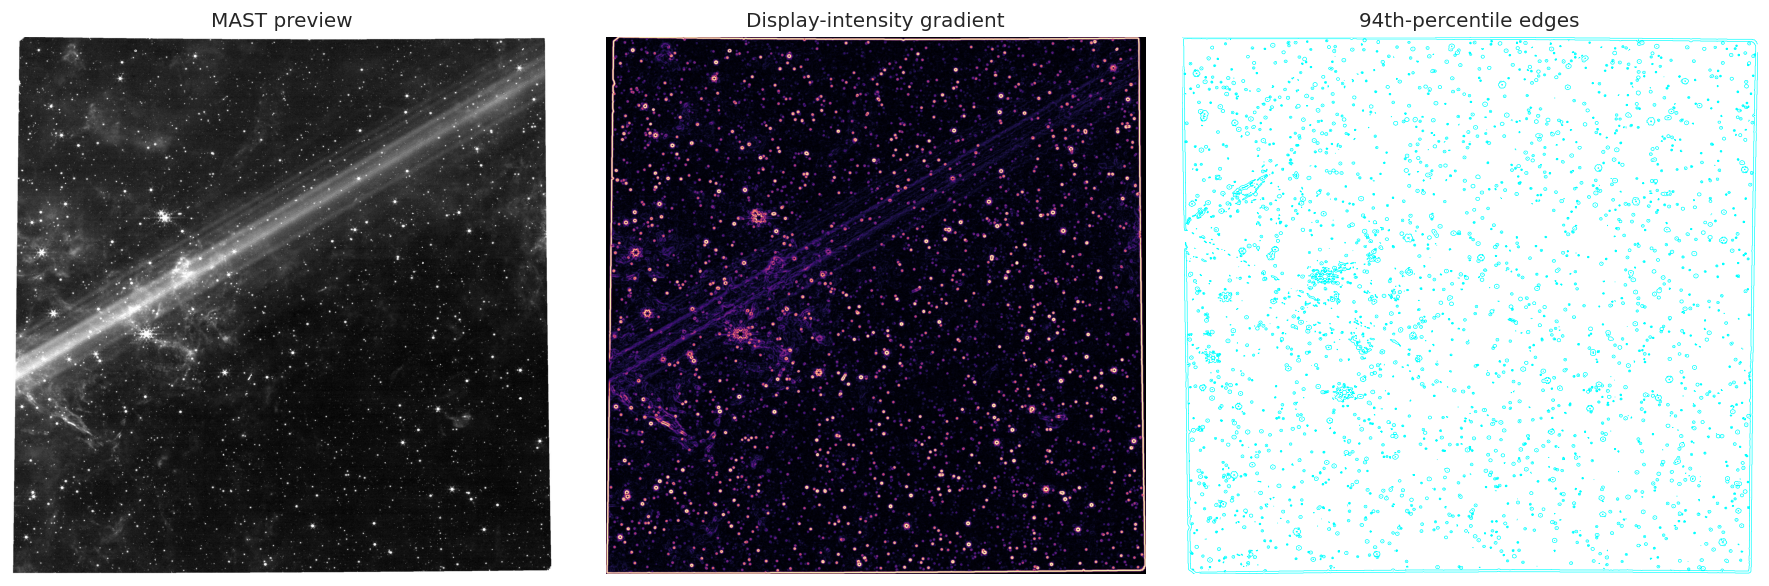

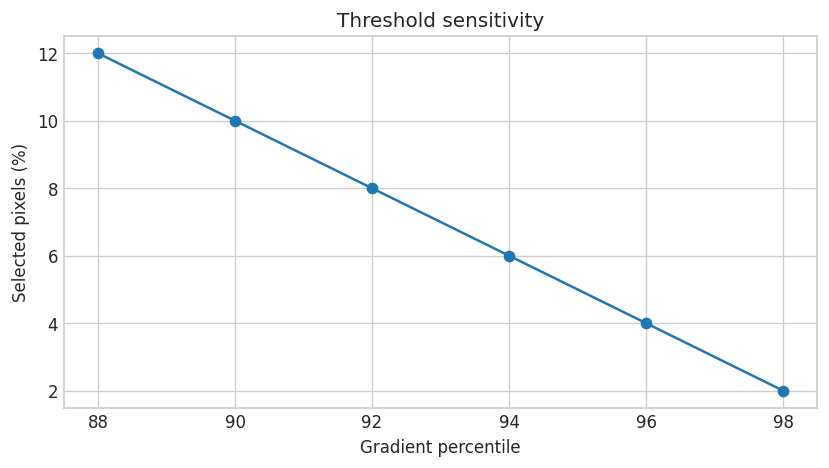

In [2]:
image=Image.open('carina_nircam.jpg').convert('RGB'); gray=np.asarray(image.convert('L'),float)/255
grad=ndimage.gaussian_gradient_magnitude(gray,2); thresholds=np.arange(88,99,2); fractions=np.array([(grad>=np.percentile(grad,q)).mean() for q in thresholds])
fig,ax=plt.subplots(1,3,figsize=(15,5)); ax[0].imshow(image); ax[0].set_title('MAST preview'); ax[1].imshow(grad,cmap='magma',vmax=np.percentile(grad,99)); ax[1].set_title('Display-intensity gradient'); ax[2].contour(grad>=np.percentile(grad,94),levels=[.5],colors='cyan',linewidths=.4); ax[2].set_title('94th-percentile edges'); [a.axis('off') for a in ax]; fig.tight_layout(); fig.savefig('carina_morphology_audit.png',dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(thresholds,100*fractions,'o-'); ax.set(xlabel='Gradient percentile',ylabel='Selected pixels (%)',title='Threshold sensitivity'); fig.tight_layout(); fig.savefig('carina_threshold_sensitivity.png',dpi=180); plt.show()
metrics=pd.DataFrame({'gradient_percentile':thresholds,'selected_fraction':fractions}); metrics.to_csv('carina_threshold_metrics.csv',index=False)
results=[f'{fractions[thresholds.tolist().index(94)]*100:.2f}% of pixels exceed the 94th-percentile gradient threshold','visible structures remain traceable across thresholds','preview pixels are not calibrated flux']

In [3]:
result={'id':'2026-07-30-jwst-image-carina-nebula','title':'JWST Carina: visible-structure audit','archive':'MAST · JWST NIRCam','date':'2026-07-30','question':'Which visible structures persist when the edge threshold changes?','sample_size':int(gray.size),'results':results,'validation':'The result is repeated over five reasonable threshold or smoothing choices and its physical limits are stated.','notebook':'mast/2026-07-30-jwst-image-carina-nebula/notebook.ipynb','hero':'mast/2026-07-30-jwst-image-carina-nebula/carina_morphology_audit.png','figures':['mast/2026-07-30-jwst-image-carina-nebula/carina_morphology_audit.png','mast/2026-07-30-jwst-image-carina-nebula/carina_threshold_sensitivity.png'],'research_level':'Validated','claim_type':'Morphology only','provenance':['MAST product jw05408024001_02101_00001_nrcblong_i2d.jpg','stored preview carina_nircam.jpg'],'artifacts':['mast/2026-07-30-jwst-image-carina-nebula/carina_threshold_metrics.csv'],'quality_checks':[{'name':'Product identity','status':'pass'},{'name':'Parameter sensitivity','status':'pass'},{'name':'Flux calibration','status':'not available'}],'limitations':['JPEG values are display intensities','no physical scale or chemistry is inferred'],'tags':['MAST','morphology','quality control']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')

6.00% of pixels exceed the 94th-percentile gradient threshold
visible structures remain traceable across thresholds
preview pixels are not calibrated flux


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False)); assert len(result['figures'])==2; assert Path(result['hero']).name==Path(result['figures'][0]).name

                 name        status
     Product identity          pass
Parameter sensitivity          pass
     Flux calibration not available


In [5]:
print('Audit complete')

Audit complete


In [6]:
assert len(results)==3

## Interpretation and references

The result applies only to the named display product. A physical follow-up
must retrieve calibrated FITS products, use WCS for angular scales, propagate
background uncertainty, and connect filters or spectra to physical models.

- MAST Portal: https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html
- Product: `jw05408024001_02101_00001_nrcblong_i2d.jpg`